# 8 &middot; Contact: a Ball Pushing into a Soft Block

Contact is just another **energy**: a penalty spring that switches on wherever a
vertex pokes inside an obstacle. We use a ball and the signed distance
\(\phi(x) = \lVert x - c\rVert - r\) (negative = inside = penalized).

We do three things:
1. a **static ball probe** &mdash; the block stays frozen while a *ghost* ball
   slides through it, and we read off the contact energy vs the ball's position,
2. a **static ground probe** &mdash; a rigid ball descends into a flat ground and
   we read off the *plane*-contact energy, which peaks when the ball is halfway
   through,
3. a **dynamic simulation** &mdash; a strong ball that visibly dents a hanging,
   pinned block.

In [2]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
from simkit.integrators import backward_euler
import utils
os.makedirs("media", exist_ok=True)

## The block, the ball, and the contact energy

`contact_springs_sphere_energy(X, k, center, r, M)` sums the penalty over every
vertex inside the ball.

In [3]:
X, T = utils.triangulated_grid(nx=10, ny=12, width=0.6, height=0.8)
X[:, 1] += 0.4                                       # hang it: y in [0, 0.8]
n, dim = X.shape
J, vol = simkit.deformation_jacobian(X, T), simkit.volume(X, T)
M_n = simkit.massmatrix(X, T, rho=1.0)
f_g = simkit.gravity_force(X, T, a=-4.0, rho=1.0).reshape(-1, 1)
mu, lam = simkit.ympr_to_lame(200.0, 0.4)            # soft, so it dents
mu  = np.full((len(T), 1), mu)
lam = np.full((len(T), 1), lam)
pin_idx = np.where(X[:, 1] >= X[:, 1].max() - 1e-6)[0]   # top edge pinned
Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, 1e6)

BALL_R = 0.16
K_CONTACT = 5e4                                      # strong contact

def signed_distance(points, center, r):
    return np.linalg.norm(points - np.asarray(center), axis=1) - r

## Experiment 1 &mdash; static probe: the block does not move

Freeze the block at its rest pose and slide a **ghost ball** up through it. We
evaluate the contact energy of that static block as a function of the ball's
position. The signed-distance background shows the contact region (blue); the
energy on the right rises exactly when the ball overlaps more of the block.


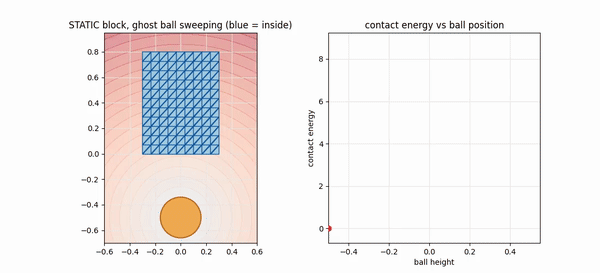

In [3]:
ball_y = np.linspace(-0.5, 0.55, 44)
centers = [np.array([0.0, cy]) for cy in ball_y]
# block is STATIC: evaluate contact energy of the rest block for each ball position
probe_energy = np.array([energies.contact_springs_sphere_energy(X, K_CONTACT, c, BALL_R, M=M_n)
                         for c in centers])
static_block = [X.copy() for _ in centers]           # block never deforms here

fig, anim = utils.animate_dynamics(static_block, T, ball_y, {"contact": probe_energy},
    lims=((-0.6, 0.6), (-0.7, 0.95)), xlabel="ball height", ylabel="contact energy",
    colors=utils.ENERGY_COLORS, ball_centers=centers, ball_radius=BALL_R, sdf=True,
    scene_title="STATIC block, ghost ball sweeping (blue = inside)",
    title="contact energy vs ball position", fps=18)
utils.save_anim(anim, "media/08_ball_probe.mp4", fps=18)
plt.close(fig)
utils.show_anim(anim)

## Experiment 2 &mdash; ground probe: energy peaks halfway through

Same idea, but now the obstacle is the **ground**. We drop a *rigid* ball toward
a flat plane and read off the **plane-contact energy** of the ball's vertices
(`contact_springs_plane_energy`). As the ball sinks in, more of it goes below the
surface and the energy climbs &mdash; reaching its **maximum when the ball is
halfway through** (its center on the ground), then falling as it rises back out.
The blue background is the ground's signed distance \(\phi(x) = y - y_{\text{ground}}\)
(negative = inside the ground). The ball here is *not* simulated; it is a probe.

peak ground-contact energy at ball-center y = 0.00  (ground at 0.0)



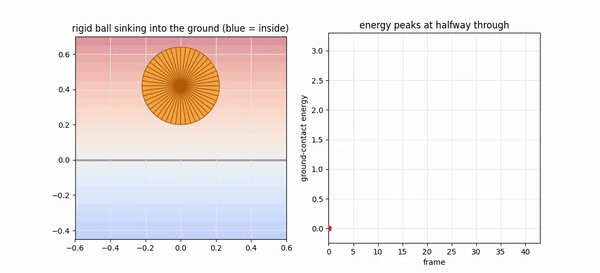

In [4]:
ball_X, ball_T = utils.ball_mesh_2d(radius=0.22, n_segments=48)
ball_M = simkit.massmatrix(ball_X, ball_T, rho=1.0)
GROUND_Y = 0.0
floor_p, floor_n = np.array([0.0, GROUND_Y]), np.array([0.0, 1.0])
K_GROUND, R2 = 5e3, 0.22

# sweep the ball center from above the ground down to ground level (halfway
# submerged) and back up; energy peaks at the deepest point
cy = np.concatenate([np.linspace(R2 + 0.2, GROUND_Y, 22), np.linspace(GROUND_Y, R2 + 0.2, 22)])
ball_states = [ball_X + np.array([0.0, y]) for y in cy]
ground_energy = np.array([energies.contact_springs_plane_energy(s, K_GROUND, floor_p, floor_n, M=ball_M)
                          for s in ball_states])
print(f"peak ground-contact energy at ball-center y = {cy[int(np.argmax(ground_energy))]:.2f}  (ground at {GROUND_Y})")

fig, anim = utils.animate_dynamics(ball_states, ball_T, np.arange(len(ball_states)),
    {"contact": ground_energy}, lims=((-0.6, 0.6), (-0.45, 0.7)),
    xlabel="frame", ylabel="ground-contact energy", colors=utils.ENERGY_COLORS,
    floor_y=GROUND_Y, floor_sdf=True, mesh_face=utils.BALL_FACE, mesh_edge=utils.BALL_EDGE,
    scene_title="rigid ball sinking into the ground (blue = inside)",
    title="energy peaks at halfway through", fps=18)
utils.save_anim(anim, "media/08_ground_probe.mp4", fps=18)
plt.close(fig)
utils.show_anim(anim)

## Experiment 3 &mdash; dynamic simulation: the ball dents the block

Now let the block respond. Each ball position is a Backward-Euler step that
minimizes elastic + pin + gravity + **strong** contact + inertia. The block
visibly deforms as the ball drives up into it.

max block displacement: 0.278



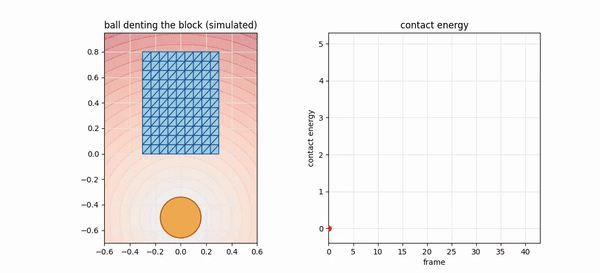

In [5]:
M = sp.sparse.kron(M_n, sp.sparse.eye(dim)).tocsc()
h = 0.02

def be_contact_step(U, U_prev, center):
    # potential only -- backward_euler adds the inertial term and Newton-solves
    def energy(x):
        xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
        E_elastic = energies.macklin_mueller_neo_hookean_energy_x(xn, J, mu, lam, vol)
        E_pin     = 0.5 * (xc.T @ (Q_pin @ xc))[0, 0] + (b_pin.T @ xc)[0, 0]
        E_gravity = -(f_g.T @ xc)[0, 0]
        E_contact = energies.contact_springs_sphere_energy(xn, K_CONTACT, center, BALL_R, M=M_n)
        return E_elastic + E_pin + E_gravity + E_contact
    def gradient(x):
        xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
        g_elastic = energies.macklin_mueller_neo_hookean_gradient_x(xn, J, mu, lam, vol)
        g_pin     = Q_pin @ xc + b_pin
        g_gravity = -f_g
        g_contact = energies.contact_springs_sphere_gradient(xn, K_CONTACT, center, BALL_R, M=M_n)
        return g_elastic + g_pin + g_gravity + g_contact
    def hessian(x):
        xn = x.reshape(-1, dim)
        H_elastic = energies.macklin_mueller_neo_hookean_hessian_x(xn, J, mu, lam, vol, psd=True)
        H_pin     = Q_pin
        H_contact = energies.contact_springs_sphere_hessian(xn, K_CONTACT, center, BALL_R, M=M_n)
        return H_elastic + H_pin + H_contact
    x = backward_euler(U.reshape(-1, 1), U_prev.reshape(-1, 1),
                       energy, gradient, hessian, M, h, max_iter=100, do_line_search=True)
    return x.reshape(n, dim)

ball_y = np.concatenate([np.linspace(-0.5, 0.4, 22), np.linspace(0.4, -0.5, 22)])
centers, states, contact_E = [], [], []
U, U_prev = X.copy(), X.copy()
for cy in ball_y:
    c_ball = np.array([0.0, cy])
    U_next = be_contact_step(U, U_prev, c_ball)
    U_prev, U = U, U_next
    centers.append(c_ball); states.append(U.copy())
    contact_E.append(energies.contact_springs_sphere_energy(U, K_CONTACT, c_ball, BALL_R, M=M_n))
print(f"max block displacement: {max(np.abs(s - X).max() for s in states):.3f}")

fig, anim = utils.animate_dynamics(states, T, np.arange(len(states)), {"contact": np.array(contact_E)},
    lims=((-0.6, 0.6), (-0.7, 0.95)), xlabel="frame", ylabel="contact energy",
    colors=utils.ENERGY_COLORS, ball_centers=centers, ball_radius=BALL_R, sdf=True,
    scene_title="ball denting the block (simulated)", title="contact energy", fps=18)
utils.save_anim(anim, "media/08_contact_ball.mp4", fps=18)
plt.close(fig)
utils.show_anim(anim)

## Experiment 4 &mdash; stiffer contact: the same ball, a firmer penalty

We **repeat Experiment 3 exactly** &mdash; same block, same pin, same gravity,
and the **same scripted ball motion** &mdash; but crank the **contact stiffness**
\(k\) up by 10&times; (`K_CONTACT_STIFF = 5e5`). A stiffer penalty spring fights
penetration harder: vertices are allowed to poke far less into the ball, so the
block is shoved away more decisively. Watch the dent grow and the contact-energy
curve climb well above the soft-contact run.

max block displacement (stiff contact): 0.497



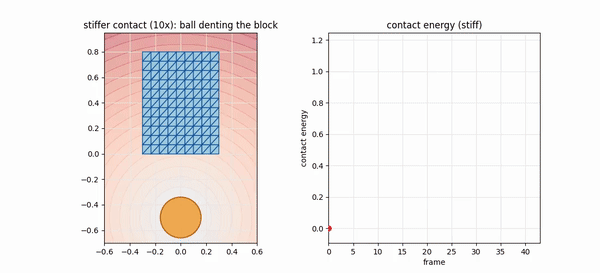

In [6]:
K_CONTACT_STIFF = 5e5                                 # 10x stiffer contact than Experiment 3

def be_contact_step_stiff(U, U_prev, center):
    # identical to Experiment 3, but the contact penalty uses K_CONTACT_STIFF
    def energy(x):
        xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
        E_elastic = energies.macklin_mueller_neo_hookean_energy_x(xn, J, mu, lam, vol)
        E_pin     = 0.5 * (xc.T @ (Q_pin @ xc))[0, 0] + (b_pin.T @ xc)[0, 0]
        E_gravity = -(f_g.T @ xc)[0, 0]
        E_contact = energies.contact_springs_sphere_energy(xn, K_CONTACT_STIFF, center, BALL_R, M=M_n)
        return E_elastic + E_pin + E_gravity + E_contact
    def gradient(x):
        xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
        g_elastic = energies.macklin_mueller_neo_hookean_gradient_x(xn, J, mu, lam, vol)
        g_pin     = Q_pin @ xc + b_pin
        g_gravity = -f_g
        g_contact = energies.contact_springs_sphere_gradient(xn, K_CONTACT_STIFF, center, BALL_R, M=M_n)
        return g_elastic + g_pin + g_gravity + g_contact
    def hessian(x):
        xn = x.reshape(-1, dim)
        H_elastic = energies.macklin_mueller_neo_hookean_hessian_x(xn, J, mu, lam, vol, psd=True)
        H_pin     = Q_pin
        H_contact = energies.contact_springs_sphere_hessian(xn, K_CONTACT_STIFF, center, BALL_R, M=M_n)
        return H_elastic + H_pin + H_contact
    x = backward_euler(U.reshape(-1, 1), U_prev.reshape(-1, 1),
                       energy, gradient, hessian, M, h, max_iter=12, do_line_search=True)
    return x.reshape(n, dim)

ball_y = np.concatenate([np.linspace(-0.5, 0.4, 22), np.linspace(0.4, -0.5, 22)])  # SAME scripted motion
centers, states_stiff, contact_E_stiff = [], [], []
U, U_prev = X.copy(), X.copy()
for cy in ball_y:
    c_ball = np.array([0.0, cy])
    U_next = be_contact_step_stiff(U, U_prev, c_ball)
    U_prev, U = U, U_next
    centers.append(c_ball); states_stiff.append(U.copy())
    contact_E_stiff.append(energies.contact_springs_sphere_energy(U, K_CONTACT_STIFF, c_ball, BALL_R, M=M_n))
print(f"max block displacement (stiff contact): {max(np.abs(s - X).max() for s in states_stiff):.3f}")

fig, anim = utils.animate_dynamics(states_stiff, T, np.arange(len(states_stiff)), {"contact": np.array(contact_E_stiff)},
    lims=((-0.6, 0.6), (-0.7, 0.95)), xlabel="frame", ylabel="contact energy",
    colors=utils.ENERGY_COLORS, ball_centers=centers, ball_radius=BALL_R, sdf=True,
    scene_title="stiffer contact (10x): ball denting the block", title="contact energy (stiff)", fps=18)
utils.save_anim(anim, "media/08_contact_ball_stiff.mp4", fps=18)
plt.close(fig)
utils.show_anim(anim)

### Takeaways
* **Penalty contact** is an energy that turns on where the signed distance is
  negative; minimizing it pushes penetrating vertices back out.
* The **static probe** shows the energy purely as a function of overlap (no
  simulation); the **dynamic** run lets the block deform in response.
* Deeper penetration &rarr; quadratically larger contact energy.
* **Contact stiffness is a knob**: a stiffer penalty (Experiment 4) tolerates
  less penetration, so the same scripted ball dents the block more and the
  contact energy spikes higher &mdash; at the cost of a stiffer, harder-to-solve
  system.